In [14]:
%load_ext autoreload
%autoreload 2

import os
import mteb
from itertools import product
from utils.dataloaders.text_dataloader import load_dataset
import numpy as np
import tqdm
import matplotlib.pyplot as plt
import omegaconf
import torch
import torch.nn as nn
import lightning as pl

from utils.model_definitions.vision_automodel_wrapper import VisionLayerwiseAutoModelWrapper, VisionModelSpecifications
from utils.dataloaders.vision_dataloader import prepare_datasets, prepare_dataloader, validation_imagenet_transform, simclr_imagenet_transform
from utils.metrics.metric_functions import compute_entropy
from utils.model_definitions.probe.LinearProbe import LinearModel
from utils.misc.optimal_batch_size import find_optimal_batch_size
from utils.dataloaders.convert_to_embeddings import convert_image_dataset_to_embeddings

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

from transformers.utils import logging
logging.set_verbosity_error()



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
def filter_dataset(dataset, classes):
    # set random seed
    np.random.seed(42)
    
    # limit to 1000 samples per class
    subsampled_indices = []
    for class_idx in classes:
        class_indices = [i for i, x in enumerate(dataset.targets) if x == class_idx]

        if len(class_indices) > 200:
            subsampled_indices.extend(np.random.choice(class_indices, size=100, replace=False))
        else:
            subsampled_indices.extend(class_indices)

    return torch.utils.data.Subset(dataset, subsampled_indices)

In [6]:
image_transform = validation_imagenet_transform()

train_dataset = prepare_datasets(
    dataset="imagenet",
    transform=image_transform,
    train_data_path="/home/AD/ofsk222/Research/exploration/information_plane/experiments/datasets/imagenet/ILSVRC/Data/CLS-LOC/train",
    number_of_samples=-1
)
val_dataset = prepare_datasets(
    dataset="imagenet",
    transform=image_transform,
    train_data_path="/home/AD/ofsk222/Research/exploration/information_plane/experiments/datasets/imagenet/ILSVRC/Data/CLS-LOC/val_sorted",
    number_of_samples=-1
)


ALL_CLASSES = np.unique(train_dataset.targets)
train_dataset = filter_dataset(train_dataset, ALL_CLASSES)
val_dataset = filter_dataset(val_dataset, ALL_CLASSES)

In [9]:
model_spec = VisionModelSpecifications(model_family="dinov2", model_size="small", revision="main")
backbone = VisionLayerwiseAutoModelWrapper(model_specs=model_spec)
print('b')

optimal_batch_size = find_optimal_batch_size(backbone, 256, device="cuda:0")

b


In [ ]:
# models_to_try = [
#     VisionModelSpecifications(model_family="dinov2", model_size="base", revision="main"),
#     VisionModelSpecifications(model_family="mae", model_size="base", revision="main"),
#     VisionModelSpecifications(model_family="clip", model_size="base", revision="main"),
#     VisionModelSpecifications(model_family="vit", model_size="base", revision="main"),  # supervised training
#     VisionModelSpecifications(model_family="i-jepa", model_size="imagenet1k", revision="main"),
#     VisionModelSpecifications(model_family="i-jepa", model_size="imagenet21k", revision="main"),
# ]   

models_to_try = [
    VisionModelSpecifications(model_family="dinov2", model_size="small", revision="main"),
    VisionModelSpecifications(model_family="dinov2", model_size="base", revision="main"),
    VisionModelSpecifications(model_family="dinov2", model_size="large", revision="main"),
    VisionModelSpecifications(model_family="dinov2", model_size="giant", revision="main"),
    # VisionModelSpecifications(model_family="dinov2-register", model_size="small", revision="main"),
    # VisionModelSpecifications(model_family="dinov2-register", model_size="base", revision="main"),
    # VisionModelSpecifications(model_family="dinov2-register", model_size="large", revision="main"),
    # VisionModelSpecifications(model_family="dinov2-register", model_size="giant", revision="main"),
    VisionModelSpecifications(model_family="mae", model_size="base", revision="main"),
    VisionModelSpecifications(model_family="mae", model_size="large", revision="main"),
    VisionModelSpecifications(model_family="mae", model_size="huge", revision="main"),
    VisionModelSpecifications(model_family="clip", model_size="base", revision="main"),
    VisionModelSpecifications(model_family="clip", model_size="large", revision="main"),
    VisionModelSpecifications(model_family="vit", model_size="base", revision="main"),
    VisionModelSpecifications(model_family="vit", model_size="large", revision="main"),
    VisionModelSpecifications(model_family="vit", model_size="huge", revision="main"),
    VisionModelSpecifications(model_family="i-jepa", model_size="imagenet1k", revision="main"),
    VisionModelSpecifications(model_family="i-jepa", model_size="imagenet21k", revision="main"),
]   

for model_spec in models_to_try:
    try:
        print(model_spec)
        save_path = f"embeddings/{model_spec.model_family}/{model_spec.model_size}/imagenet"
        backbone = VisionLayerwiseAutoModelWrapper(model_specs=model_spec)

        optimal_batch_size = find_optimal_batch_size(backbone, 256, device="cuda:0")

        train_save_path = f"{save_path}/train.pt"
        if not os.path.exists(train_save_path):
            train_dataloader = prepare_dataloader(train_dataset, batch_size=optimal_batch_size, num_workers=64, shuffle=True)
            convert_image_dataset_to_embeddings(train_dataloader, backbone, train_save_path)

        val_save_path = f"{save_path}/val.pt"
        if not os.path.exists(val_save_path):
            val_dataloader = prepare_dataloader(val_dataset, batch_size=optimal_batch_size, num_workers=64, shuffle=False)
            convert_image_dataset_to_embeddings(val_dataloader, backbone, val_save_path)

        del backbone
        torch.cuda.empty_cache()
    except Exception as e:
        print(e)



        Model family: dinov2
        Model size: small
        Revision: main
        

        Model family: dinov2
        Model size: base
        Revision: main
        

        Model family: dinov2
        Model size: large
        Revision: main
        


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7fa6392cdfc0>>
Traceback (most recent call last):
  File "/home/AD/ofsk222/miniconda3/envs/information_plane/lib/python3.10/site-packages/ipykernel/ipkernel.py", line 770, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 
Converting set to embeddings:   0%|          | 0/195 [00:00<?, ?it/s]

In [16]:
# loaded_train_dataset = torch.load(f"{save_path}/train.pt")
# loaded_val_dataset = torch.load(f"{save_path}/val.pt")


In [4]:
# from sklearn.preprocessing import StandardScaler
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# def process_layer(x_train, x_test, y_train, y_test):
#     normalized_X_train = StandardScaler().fit_transform(x_train) 
#     normalized_X_test = StandardScaler().fit_transform(x_test)

#     clf = LogisticRegression(
#         n_jobs=2,
#         max_iter=250
#     )
#     clf.fit(normalized_X_train, y_train)
#     y_pred = clf.predict(normalized_X_test)
    
#     return {
#         'accuracy': accuracy_score(y_test, y_pred),
#         'f1': f1_score(y_test, y_pred, average='macro'),
#         'precision': precision_score(y_test, y_pred, average='macro'),
#         'recall': recall_score(y_test, y_pred, average='macro')
#     }


In [17]:
# len(loaded_train_dataset)

9728

In [21]:
# # use loaded_train_dataset and loaded_val_dataset
# # note that loaded_train_dataset is a list of tuples (sample_embedding, sample_label)
# x_train = np.array([x[0] for x in loaded_train_dataset])[:, -1, :]
# y_train = np.array([x[1] for x in loaded_train_dataset])
# x_test = np.array([x[0] for x in loaded_val_dataset])[:, -1, :]
# y_test = np.array([x[1] for x in loaded_val_dataset])

# result = process_layer(x_train, x_test, y_train, y_test)

/home/AD/ofsk222/miniconda3/envs/information_plane/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [4]:
# cfg = omegaconf.OmegaConf.create({
#     "data": {
#         "num_classes": 1000,
#     },
#     "scheduler": {
#         "lr_decay_steps": [60, 80],
#     },
#     "optimizer": {
#         "weight_decay": 0.01,
#         "name": "adam",
#         "batch_size": 1024,
#         "lr": 0.001,
#     },
#     "max_epochs": 2,
# })


In [5]:
# backbone = VisionLayerwiseAutoModelWrapper(model_specs=models_to_try[0])
# probe = LinearModel(backbone=backbone, cfg=cfg)

In [6]:
# trainer = pl.Trainer(max_epochs=cfg.max_epochs, callbacks=[], logger=False, devices=1)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs


In [7]:
# trainer.fit(probe, train_dataloader, val_dataloader)

INFO: You are using a CUDA device ('NVIDIA RTX A5000') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
INFO:lightning.pytorch.utilities.rank_zero:You are using a CUDA device ('NVIDIA RTX A5000') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
INFO: 
  | Name       | Type             | Params | Mode 
--------------------------------------------

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

INFO: 
Detected KeyboardInterrupt, attempting graceful shutdown ...
INFO:lightning.pytorch.utilities.rank_zero:
Detected KeyboardInterrupt, attempting graceful shutdown ...


In [4]:
# backbone = VisionLayerwiseAutoModelWrapper(model_specs=models_to_try[0])
# backbone.model = backbone.model.to("cuda:0")

In [2]:
import pickle

with open(f"results/dinov2/base/imagenet/layer_9.pkl", "rb") as f:
    accuracies = pickle.load(f)

accuracies

{'train_loss': tensor(6.7127),
 'train_loss_step': tensor(6.6891),
 'train_acc1': tensor(9.2427),
 'train_acc1_step': tensor(10.3516),
 'train_acc5': tensor(23.1687),
 'train_acc5_step': tensor(25.4883),
 'val_loss': tensor(6.6969),
 'val_acc1': tensor(9.1797),
 'val_acc5': tensor(23.7355),
 'train_loss_epoch': tensor(6.7127),
 'train_acc1_epoch': tensor(9.2427),
 'train_acc5_epoch': tensor(23.1687)}

In [7]:
# for batch in tqdm.tqdm(train_dataloader):
#     pass

100%|██████████| 312/312 [00:06<00:00, 49.44it/s] 


In [5]:

# for batch in tqdm.tqdm(train_dataloader):
#     X, target = backbone.prepare_inputs(batch)
#     feats = backbone(**X)
    

  0%|          | 0/1251 [00:31<?, ?it/s]


KeyboardInterrupt: 

# Show Image Results

In [4]:
import pickle
import matplotlib.pyplot as plt

image_models = ["dinov2", "mae", "clip", "vit"]
model_to_results = {}
for model in image_models:
    model_to_results[model] = []
    for layer in range(12):
        with open(f"results/{model}/base/imagenet/layer_{layer}.pkl", "rb") as f:
            accuracies = pickle.load(f)
        model_to_results[model].append(accuracies)


In [6]:
model_to_results["dinov2"]

[{'train_loss': 6.903450012207031,
  'train_loss_step': 6.903873443603516,
  'train_acc1': 0.27064284682273865,
  'train_acc1_step': 0.29296875,
  'train_acc5': 1.0782779455184937,
  'train_acc5_step': 0.9114583134651184,
  'val_loss': 6.904472827911377,
  'val_acc1': 0.304043173789978,
  'val_acc5': 1.1215367317199707,
  'train_loss_epoch': 6.903450012207031,
  'train_acc1_epoch': 0.27064284682273865,
  'train_acc5_epoch': 1.0782779455184937},
 {'train_loss': 6.904542922973633,
  'train_loss_step': 6.904550075531006,
  'train_acc1': 0.27993229031562805,
  'train_acc1_step': 0.1302083283662796,
  'train_acc5': 1.121212363243103,
  'train_acc5_step': 1.1393228769302368,
  'val_loss': 6.905004024505615,
  'val_acc1': 0.2355831116437912,
  'val_acc5': 1.0792526006698608,
  'train_loss_epoch': 6.904542922973633,
  'train_acc1_epoch': 0.27993229031562805,
  'train_acc5_epoch': 1.121212363243103},
 {'train_loss': 6.905659198760986,
  'train_loss_step': 6.905965328216553,
  'train_acc1': 0.32

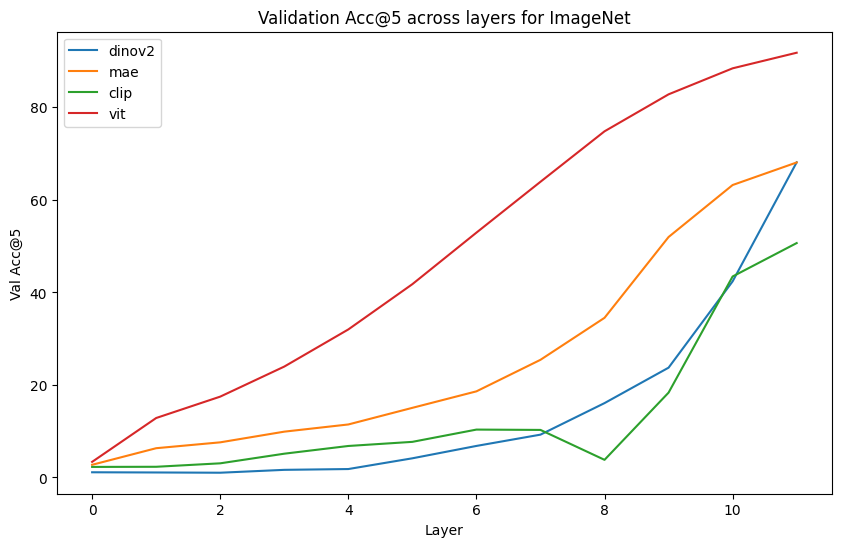

In [11]:
# plot the results across layers

plt.figure(figsize=(10, 6))
for model in image_models:
    layer_val_1 = [x["val_acc5"] for x in model_to_results[model]]
    plt.plot(layer_val_1, label=model)
plt.xlabel("Layer")
plt.ylabel("Val Acc@5")
plt.title("Validation Acc@5 across layers for ImageNet")
plt.legend()
plt.show()
